In [1]:
import torch
from transformers import BertTokenizer, BertForNextSentencePrediction, Trainer, TrainingArguments
from datasets import Dataset, load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
sentences = [
    ("The quick brown fox jumps over the lazy dog.", "The dog was not amused.", 1),  
    ("The quick brown fox jumps over the lazy dog.", "I love eating pizza.", 0),    
    ("She opened the door.", "She saw her friend standing there.", 1),               
    ("She opened the door.", "The sky was blue.", 0),                                
    ("He went to the store.", "He bought some groceries.", 1),                      
    ("He went to the store.", "It started raining heavily.", 0)                     
]

dataset = Dataset.from_dict({
    "sentence1": [s[0] for s in sentences],
    "sentence2": [s[1] for s in sentences],
    "label": [s[2] for s in sentences]
})

train_test_split = dataset.train_test_split(test_size=0.2)
train_dataset = train_test_split['train']
test_dataset = train_test_split['test']

In [3]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['sentence1'], examples['sentence2'], truncation=True, padding='max_length', max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

In [4]:
model = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')

In [5]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="epoch",
)

In [6]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [7]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)


trainer.train()

eval_results = trainer.evaluate()
print(f"\nEvaluation Results: {eval_results}")

c:\Users\AE\Desktop\b\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


c:\Users\AE\Desktop\b\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AE\Desktop\b\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\AE\Desktop\b\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Evaluation Results: {'eval_loss': 2.2109344005584717, 'eval_accuracy': 0.5, 'eval_runtime': 0.106, 'eval_samples_per_second': 18.877, 'eval_steps_per_second': 9.438, 'epoch': 3.0}


c:\Users\AE\Desktop\b\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Number of test samples: 2


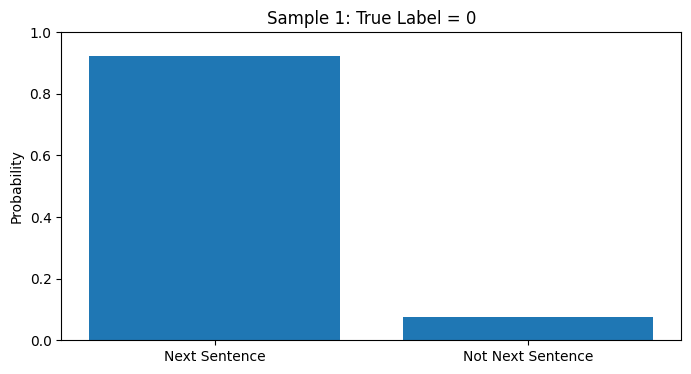

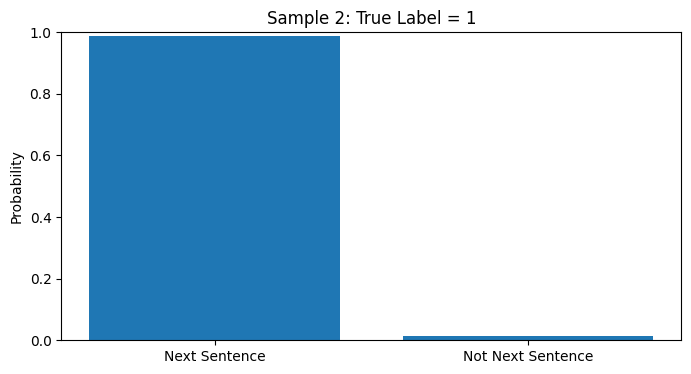

In [9]:
predictions = trainer.predict(test_dataset)
probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

# Get the actual number of test samples
num_test_samples = len(test_dataset)
print(f"Number of test samples: {num_test_samples}")

# Plot predictions for all available test samples
for i in range(num_test_samples):  
    plt.figure(figsize=(8, 4))
    plt.bar(['Next Sentence', 'Not Next Sentence'], probs[i])
    plt.title(f"Sample {i+1}: True Label = {test_dataset[i]['label']}")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.show()